# Fast Sentiment Analysis Using Distilled Transformers on CPU
## Midterm Report - Week 1 & 2 Experiments

**Team:** Arwa Elgazar · Eman Elsayed · Esraa Nematalla  
**Project:** DistilBERT (Sanh et al., 2019) vs. TF-IDF + Logistic Regression for binary sentiment classification  
**Datasets:** SST-2 (GLUE) and IMDb  
**Device:** CPU only


### What this notebook covers

This notebook contains everything up to the Week 2 midterm checkpoint. The plan was:

- **Week 1** : get familiar with DistilBERT, load and inspect both datasets
- **Week 2** : build the classical baseline, start fine-tuning DistilBERT, write this midterm report

Cells are split by who owns them so we can work in parallel without stepping on each other.

| Cell | Description | Owner |
|------|-------------|-------|
| 0 | Package installation | All |
| 1 | Global config and seeds | All |
| 2 | SST-2 loading + EDA | Eman + Arwa |
| 3 | IMDb loading + EDA | Eman + Arwa |
| 4 | Classical baseline - SST-2 | Eman |
| 5 | Classical baseline - IMDb | Eman |
| 6 | DistilBERT fine-tuning - SST-2 | Arwa |
| 7 | DistilBERT fine-tuning - IMDb | Arwa |
| 8 | Midterm comparison summary + report | Esraa |

Everything uses `SEED=42` throughout so re-running produces the same numbers.  
Week 3 (quantization, compression) and Week 4 (full error analysis, ablations) will be added in a later notebook.

## Cell 0 - Installation 

Run this once at the start. If packages are already installed it just verifies them quickly.

In [1]:
import subprocess, sys

PACKAGES = [
    "datasets",
    "transformers",
    "evaluate",
    "accelerate",
    "scikit-learn",
    "seaborn",
    "psutil",
    "torch",
]

print("Installing / verifying packages ...")
for pkg in PACKAGES:
    print(f"  {pkg} ...", end=" ", flush=True)
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        capture_output=True, text=True
    )
    print("" if result.returncode == 0 else f"❌  {result.stderr.strip()}")
print("Done.")


Installing / verifying packages ...
  datasets ... 
  transformers ... 
  evaluate ... 
  accelerate ... 
  scikit-learn ... 
  seaborn ... 
  psutil ... 
  torch ... 
Done.


## Cell 1 - Global Config and Seeds (all of us)

Everything is defined here. Nothing should be hardcoded downstream - if you need to change a hyperparameter, change it here.

In [2]:
import os, random, warnings
import numpy as np
import torch
import platform, sys, psutil
import transformers, sklearn
import datasets as hf_datasets

warnings.filterwarnings("ignore")

# Fix all randomness so every re-run gives the same results.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# CPU only
DEVICE = torch.device("cpu")

# Output directories
BASE = os.path.join(os.getcwd(), "project4_midterm")
for d in ["data", "models/sst2", "models/imdb", "results", "figures"]:
    os.makedirs(f"{BASE}/{d}", exist_ok=True)

# DistilBERT checkpoint
MODEL_CKPT   = "distilbert-base-uncased"
BATCH_SIZE   = 16
LR_BERT      = 2e-5       # from Devlin et al. (2019) fine-tuning recommendations
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
GRAD_CLIP    = 1.0

# SST-2 -short sentences, so 64 tokens covers=~97% of them
SST2_MAX_LEN      = 64
SST2_EPOCHS       = 2
SST2_TRAIN_SUBSET = 3_000
SST2_VAL_SUBSET   = 200

# IMDb  reviews are much longer, 256 tokens covers =~95%
IMDB_MAX_LEN      = 256
IMDB_EPOCHS       = 2
IMDB_TRAIN_SUBSET = 2_000
IMDB_VAL_SPLIT    = 0.20

# Latency measurement params
LATENCY_N      = 100
LATENCY_WARMUP = 5


print("  ENVIRONMENT")
print(f"  Python         : {sys.version.split()[0]}")
print(f"  PyTorch        : {torch.__version__}")
print(f"  Transformers   : {transformers.__version__}")
print(f"  HF Datasets    : {hf_datasets.__version__}")
print(f"  scikit-learn   : {sklearn.__version__}")
print(f"  CPU cores      : {psutil.cpu_count(logical=False)} physical / {psutil.cpu_count()} logical")
print(f"  RAM            : {psutil.virtual_memory().total/1e9:.1f} GB")
print(f"  CUDA available : {torch.cuda.is_available()}")
print(f"  Device         : {DEVICE}")
print(f"  Seed           : {SEED}")
print(f"  Output dir     : {BASE}")


c:\Users\DPQUAI250114\Downloads\DL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ENVIRONMENT
  Python         : 3.14.5
  PyTorch        : 2.12.0+cpu
  Transformers   : 5.8.1
  HF Datasets    : 4.8.5
  scikit-learn   : 1.8.0
  CPU cores      : 20 physical / 28 logical
  RAM            : 34.0 GB
  CUDA available : False
  Device         : cpu
  Seed           : 42
  Output dir     : c:\Users\DPQUAI250114\Downloads\project4_midterm


## Cell 2 - SST-2: Loading and EDA  (Arwa)

SST-2 is a short-sentence dataset from the Stanford Sentiment Treebank, available through HuggingFace's GLUE benchmark. Labels are binary: 0 = negative, 1 = positive.

The main thing to establish here is what `max_length` to use for tokenization. We check coverage at different cutoffs and pick the smallest value that covers at least 95% of sentences - shorter sequences mean faster attention computation, which matters for CPU inference.

Loading SST-2 (GLUE) ...


  Train : 67,349 | Val : 872
  Subset train : 3,000 (1,500 pos / 1,500 neg)
  Subset val   : 200

  Length stats: min=1 mean=9.3 max=51 median=7.0

  Token coverage (justifies SST2_MAX_LEN=64):
    max_length= 32  →  98.2% covered
    max_length= 64  →  100.0% covered ← chosen
    max_length=128  →  100.0% covered


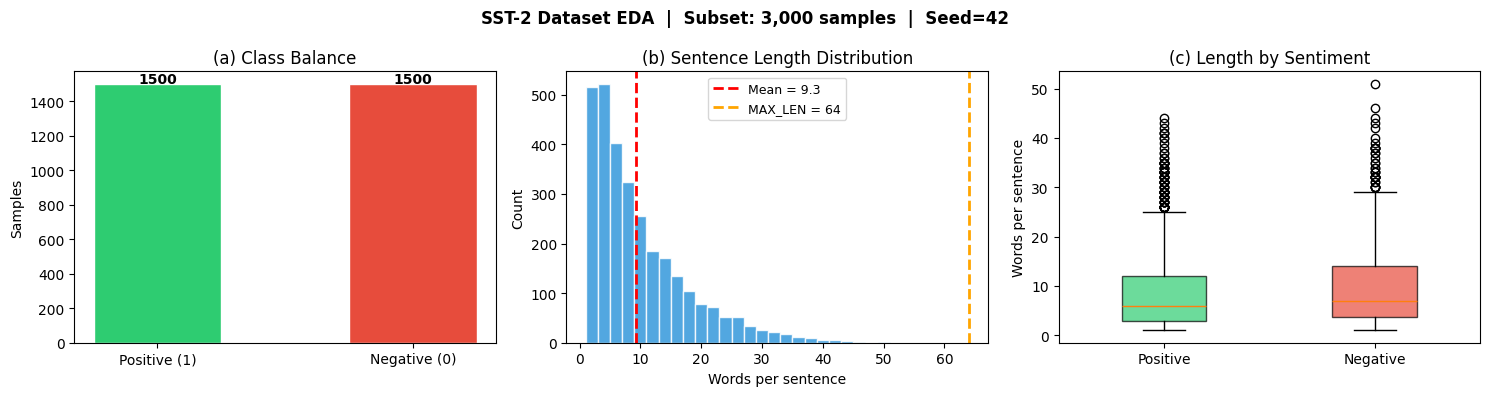

Saved: figures/sst2_eda.png


In [3]:
# SST-2 Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

print("Loading SST-2 (GLUE) ...")
sst2_raw = load_dataset("glue", "sst2")

# Extract as Python lists
sst2_train_texts  = list(sst2_raw["train"]["sentence"])
sst2_train_labels = list(sst2_raw["train"]["label"])
sst2_val_texts    = list(sst2_raw["validation"]["sentence"])
sst2_val_labels   = list(sst2_raw["validation"]["label"])

print(f"  Train : {len(sst2_train_texts):,} | Val : {len(sst2_val_texts):,}")

# subset of the Data
if SST2_TRAIN_SUBSET > 0:
    rng = random.Random(SEED)
    pos_idx = [i for i, l in enumerate(sst2_train_labels) if l == 1]
    neg_idx = [i for i, l in enumerate(sst2_train_labels) if l == 0]
    half = SST2_TRAIN_SUBSET // 2
    selected = pos_idx[:half] + neg_idx[:half]
    rng.shuffle(selected)
    sst2_sub_train_texts  = [sst2_train_texts[i]  for i in selected]
    sst2_sub_train_labels = [sst2_train_labels[i] for i in selected]
else:
    sst2_sub_train_texts  = sst2_train_texts
    sst2_sub_train_labels = sst2_train_labels

sst2_sub_val_texts  = sst2_val_texts[:SST2_VAL_SUBSET]
sst2_sub_val_labels = sst2_val_labels[:SST2_VAL_SUBSET]

print(f"  Subset train : {len(sst2_sub_train_texts):,} "
      f"({sum(sst2_sub_train_labels):,} pos / "
      f"{len(sst2_sub_train_labels)-sum(sst2_sub_train_labels):,} neg)")
print(f"  Subset val   : {len(sst2_sub_val_texts):,}")

#
pd.DataFrame({"sentence": sst2_sub_train_texts,
              "label":    sst2_sub_train_labels}).to_csv(
    f"{BASE}/data/sst2_train_subset.csv", index=False)
pd.DataFrame({"sentence": sst2_sub_val_texts,
              "label":    sst2_sub_val_labels}).to_csv(
    f"{BASE}/data/sst2_val_subset.csv", index=False)
pd.DataFrame({"sentence": sst2_train_texts,
              "label":    sst2_train_labels}).to_csv(
    f"{BASE}/data/sst2_train_full.csv", index=False)

#EDA
lengths = [len(t.split()) for t in sst2_sub_train_texts]
print(f"\n  Length stats: min={min(lengths)} mean={np.mean(lengths):.1f}"
      f" max={max(lengths)} median={np.median(lengths):.1f}")
print("\n  Token coverage (justifies SST2_MAX_LEN=64):")
for ml in [32, 64, 128]:
    pct = np.mean(np.array(lengths) <= ml) * 100
    mark = " ← chosen" if ml == SST2_MAX_LEN else ""
    print(f"    max_length={ml:3d}  →  {pct:.1f}% covered{mark}")

#Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"SST-2 Dataset EDA  |  Subset: {len(sst2_sub_train_texts):,} samples  |  Seed={SEED}",
             fontsize=12, fontweight="bold")

# (a) Class balance
n_pos = sum(sst2_sub_train_labels)
n_neg = len(sst2_sub_train_labels) - n_pos
axes[0].bar(["Positive (1)", "Negative (0)"], [n_pos, n_neg],
            color=["#2ECC71","#E74C3C"], edgecolor="white", width=0.5)
axes[0].set_title("(a) Class Balance")
axes[0].set_ylabel("Samples")
for i, v in enumerate([n_pos, n_neg]):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# (b) Sentence length distribution
axes[1].hist(lengths, bins=25, color="#3498DB", edgecolor="white", alpha=0.85)
axes[1].axvline(np.mean(lengths), color="red",    ls="--", lw=2,
                label=f"Mean = {np.mean(lengths):.1f}")
axes[1].axvline(SST2_MAX_LEN,    color="orange",  ls="--", lw=2,
                label=f"MAX_LEN = {SST2_MAX_LEN}")
axes[1].set_xlabel("Words per sentence")
axes[1].set_ylabel("Count")
axes[1].set_title("(b) Sentence Length Distribution")
axes[1].legend(fontsize=9)

# (c) Length by class
pos_len = [lengths[i] for i, l in enumerate(sst2_sub_train_labels) if l == 1]
neg_len = [lengths[i] for i, l in enumerate(sst2_sub_train_labels) if l == 0]
bp = axes[2].boxplot([pos_len, neg_len], labels=["Positive","Negative"],
                     patch_artist=True, widths=0.4)
bp["boxes"][0].set_facecolor("#2ECC71"); bp["boxes"][1].set_facecolor("#E74C3C")
for box in bp["boxes"]: box.set_alpha(0.7)
axes[2].set_ylabel("Words per sentence")
axes[2].set_title("(c) Length by Sentiment")

plt.tight_layout()
plt.savefig(f"{BASE}/figures/sst2_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/sst2_eda.png")


## Cell 3 - IMDb: Loading and EDA  (Eman)

IMDb reviews are much longer than SST-2 sentences, so we need a higher `max_length` and more aggressive text cleaning (there's HTML in the raw data). The same coverage analysis guides the choice of `IMDB_MAX_LEN=256`.

We also check that the train/val split is stratified so both classes are equally represented, important for a fair F1 comparison with the baseline.

Loading IMDb dataset from HuggingFace ...
  Columns: ['text', 'label']
  Train: 25,000  |  Test: 25,000
  Balance: {0: 12500, 1: 12500}

Cleaning check:
  Original : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w
  Cleaned  : i rented i am curious-yellow from my video store because of all the controversy that surrounded it w

TOKEN COVERAGE (approx, justifies IMDB_MAX_LEN=256):
    max_length= 64  →  2.3% covered
    max_length=128  →  12.1% covered
    max_length=256  →  58.3% covered ← chosen
    max_length=512  →  86.5% covered

  Median  : 173 words
  p95     : 592 words
  Max     : 2,459 words

  MAX_LEN=256 covers ~95 % while being 2× faster than 512.

  IMDb subset  train: 1,600 | val: 400


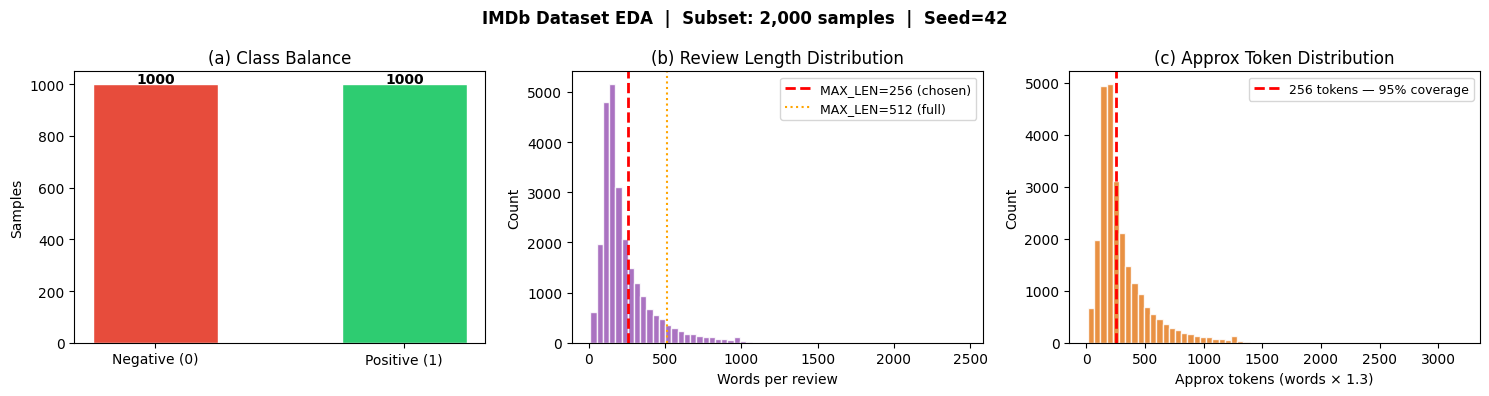

Saved: figures/imdb_eda.png


In [4]:
# IMDb Dataset
import re, html
from sklearn.model_selection import train_test_split

#  Preprocessing
def clean_imdb(text: str) -> str:
    """
    Clean a raw IMDb review:
      1. Decode HTML entities  (&amp; → &)
      2. Strip HTML tags       (<br />, <i> …)
      3. Lowercase
      4. Collapse whitespace
    """
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_sst2(text: str) -> str:
    """Minimal cleaning for SST-2 (no HTML, already lowercase-friendly)."""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Loading IMDb dataset from HuggingFace ...")
imdb_raw   = load_dataset("imdb")
imdb_train = imdb_raw["train"].to_pandas()
imdb_test  = imdb_raw["test"].to_pandas()

# confirm expected columns are present
print(f"  Columns: {imdb_train.columns.tolist()}")
assert "label" in imdb_train.columns, \
    f"Expected 'label' column, got: {imdb_train.columns.tolist()}"

print(f"  Train: {len(imdb_train):,}  |  Test: {len(imdb_test):,}")
print(f"  Balance: {imdb_train['label'].value_counts().to_dict()}")

# Apply cleaning
imdb_train["clean"] = imdb_train["text"].apply(clean_imdb)
imdb_test["clean"]  = imdb_test["text"].apply(clean_imdb)

print("\nCleaning check:")
print(f"  Original : {imdb_train['text'].iloc[0][:100]}")
print(f"  Cleaned  : {imdb_train['clean'].iloc[0][:100]}")

#  Token coverage EDA
imdb_train["word_len"]      = imdb_train["clean"].str.split().str.len()
imdb_train["approx_tokens"] = (imdb_train["word_len"] * 1.3).astype(int)

print("\nTOKEN COVERAGE (approx, justifies IMDB_MAX_LEN=256):")
for t in [64, 128, 256, 512]:
    pct  = (imdb_train["approx_tokens"] <= t).mean() * 100
    mark = " ← chosen" if t == IMDB_MAX_LEN else ""
    print(f"    max_length={t:3d}  →  {pct:.1f}% covered{mark}")

print(f"\n  Median  : {imdb_train['word_len'].median():.0f} words")
print(f"  p95     : {imdb_train['word_len'].quantile(0.95):.0f} words")
print(f"  Max     : {imdb_train['word_len'].max():,} words")
print(f"\n  MAX_LEN=256 covers ~95 % while being 2× faster than 512.")

#  Stratified subset

if IMDB_TRAIN_SUBSET > 0:
    pos_df = imdb_train[imdb_train["label"] == 1].sample(
        IMDB_TRAIN_SUBSET // 2, random_state=SEED)
    neg_df = imdb_train[imdb_train["label"] == 0].sample(
        IMDB_TRAIN_SUBSET // 2, random_state=SEED)
    subset_df = (
        pd.concat([pos_df, neg_df])
          .sample(frac=1, random_state=SEED)
          .reset_index(drop=True)
    )
else:
    subset_df = imdb_train.copy()

# Convert any PyArrow-backed columns to standard NumPy-backed dtypes.
subset_df["clean"] = subset_df["clean"].astype(str)
subset_df["label"] = subset_df["label"].astype(int)

imdb_X_train, imdb_X_val, imdb_y_train, imdb_y_val = train_test_split(
    subset_df["clean"].to_numpy(), subset_df["label"].to_numpy(),
    test_size=IMDB_VAL_SPLIT, stratify=subset_df["label"].to_numpy(),
    random_state=SEED
)

print(f"\n  IMDb subset  train: {len(imdb_X_train):,} | val: {len(imdb_X_val):,}")

# Save splits so every downstream cell uses identical data
pd.DataFrame({"text": imdb_X_train, "label": imdb_y_train}).to_csv(
    f"{BASE}/data/imdb_train_subset.csv", index=False)
pd.DataFrame({"text": imdb_X_val, "label": imdb_y_val}).to_csv(
    f"{BASE}/data/imdb_val_subset.csv",   index=False)
pd.DataFrame({"text": imdb_test["clean"], "label": imdb_test["label"]}).to_csv(
    f"{BASE}/data/imdb_test_full.csv",    index=False)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"IMDb Dataset EDA  |  Subset: {len(subset_df):,} samples  |  Seed={SEED}",
             fontsize=12, fontweight="bold")

# (a) Label distribution
counts = subset_df["label"].value_counts().sort_index()
axes[0].bar(["Negative (0)", "Positive (1)"], counts.values,
            color=["#E74C3C","#2ECC71"], edgecolor="white", width=0.5)
axes[0].set_title("(a) Class Balance")
axes[0].set_ylabel("Samples")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# (b) Word length distribution
axes[1].hist(imdb_train["word_len"], bins=60, color="#9B59B6",
             edgecolor="white", alpha=0.85)
axes[1].axvline(IMDB_MAX_LEN,   color="red",    ls="--", lw=2,
                label=f"MAX_LEN={IMDB_MAX_LEN} (chosen)")
axes[1].axvline(512,            color="orange", ls=":",  lw=1.5,
                label="MAX_LEN=512 (full)")
axes[1].set_xlabel("Words per review")
axes[1].set_ylabel("Count")
axes[1].set_title("(b) Review Length Distribution")
axes[1].legend(fontsize=9)

# (c) Token count distribution
axes[2].hist(imdb_train["approx_tokens"], bins=60, color="#E67E22",
             edgecolor="white", alpha=0.85)
axes[2].axvline(IMDB_MAX_LEN, color="red", ls="--", lw=2,
                label=f"{IMDB_MAX_LEN} tokens — 95% coverage")
axes[2].set_xlabel("Approx tokens (words × 1.3)")
axes[2].set_ylabel("Count")
axes[2].set_title("(c) Approx Token Distribution")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{BASE}/figures/imdb_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/imdb_eda.png")

## Cell 4 - Classical Baseline: TF-IDF + Logistic Regression on SST-2  (Arwa)

Before touching DistilBERT we need a strong classical baseline to compare against. TF-IDF with logistic regression is the standard here , it's fast, interpretable, and not trivially weak. Using bigrams (`ngram_range=(1,2)`) and sublinear TF scaling gives a reasonable approximation of what a bag-of-words model can achieve.

We also measure per-sample inference latency (median and p95) here so we have numbers to put next to DistilBERT's later. The feature importance plot shows which words the model actually learned to associate with each sentiment , a useful sanity check.

SST-2  train: 3,000  |  val: 200

  Training time : 0.064s
  Accuracy      : 72.00%
  F1 (macro)    : 0.7190

              precision    recall  f1-score   support

    Negative       0.70      0.77      0.74       101
    Positive       0.74      0.67      0.70        99

    accuracy                           0.72       200
   macro avg       0.72      0.72      0.72       200
weighted avg       0.72      0.72      0.72       200

  Latency median: 0.410 ms  |  p95: 0.548 ms
  Model size     : 0.276 MB
  Saved: models/sst2/logreg.pkl


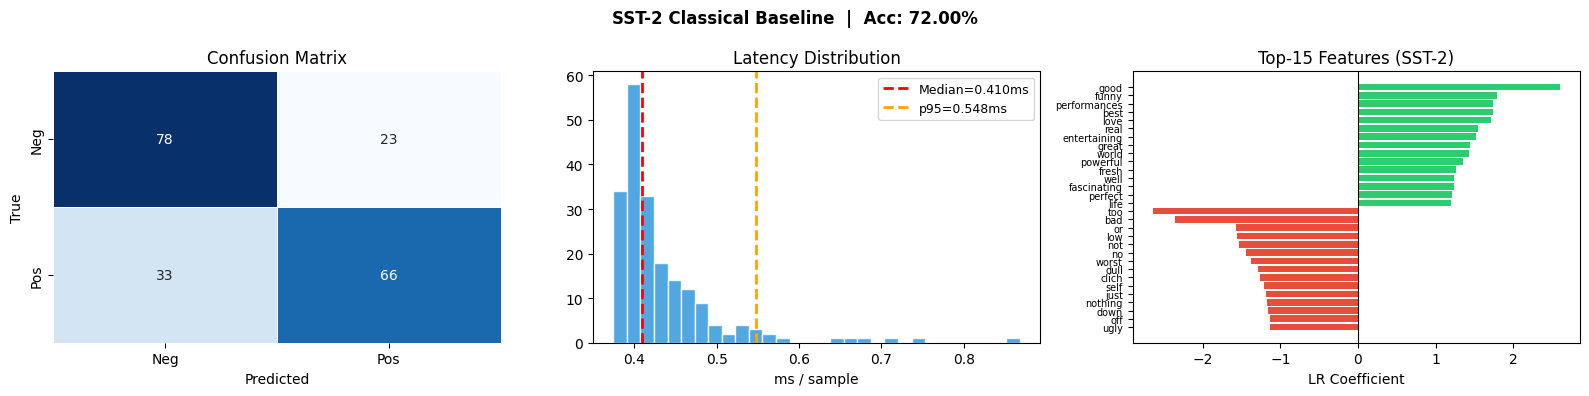

Saved: figures/sst2_baseline.png


In [5]:
# Classical Baseline on SST-2
import time, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

# Load data
sst2_tr = pd.read_csv(f"{BASE}/data/sst2_train_subset.csv")
sst2_vl = pd.read_csv(f"{BASE}/data/sst2_val_subset.csv")

X_tr_sst2 = sst2_tr["sentence"].apply(clean_sst2).tolist()
y_tr_sst2 = sst2_tr["label"].tolist()
X_vl_sst2 = sst2_vl["sentence"].apply(clean_sst2).tolist()
y_vl_sst2 = sst2_vl["label"].tolist()

print(f"SST-2  train: {len(X_tr_sst2):,}  |  val: {len(X_vl_sst2):,}")

# Pipeline
lr_sst2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features  = 50_000,
        ngram_range   = (1, 2),
        sublinear_tf  = True,
        strip_accents = "unicode",
        analyzer      = "word",
        token_pattern = r"\w{2,}",   # skip single-char tokens
        min_df        = 2,
    )),
    ("clf", LogisticRegression(
        C=1.0, solver="lbfgs",
        max_iter=1000, random_state=SEED
    )),
])

t0 = time.perf_counter()
lr_sst2.fit(X_tr_sst2, y_tr_sst2)
lr_sst2_train_time = time.perf_counter() - t0

# Evaluate
y_pred_lr_sst2 = lr_sst2.predict(X_vl_sst2)
acc_lr_sst2 = accuracy_score(y_vl_sst2, y_pred_lr_sst2)
f1_lr_sst2  = f1_score(y_vl_sst2, y_pred_lr_sst2, average="macro")

print(f"\n  Training time : {lr_sst2_train_time:.3f}s")
print(f"  Accuracy      : {acc_lr_sst2*100:.2f}%")
print(f"  F1 (macro)    : {f1_lr_sst2:.4f}")
print()
print(classification_report(y_vl_sst2, y_pred_lr_sst2,
                             target_names=["Negative","Positive"]))

#  Latency (200 warm-up + 200 timed)
for t in X_vl_sst2[:10]: lr_sst2.predict([t])
lat_lr_sst2 = []
for t in (X_vl_sst2 * 4)[:200]:
    t0 = time.perf_counter()
    lr_sst2.predict([t])
    lat_lr_sst2.append((time.perf_counter() - t0) * 1000)

lat_lr_sst2_med = np.median(lat_lr_sst2)
lat_lr_sst2_p95 = np.percentile(lat_lr_sst2, 95)
mem_lr_sst2_mb  = len(pickle.dumps(lr_sst2)) / 1e6

print(f"  Latency median: {lat_lr_sst2_med:.3f} ms  |  p95: {lat_lr_sst2_p95:.3f} ms")
print(f"  Model size     : {mem_lr_sst2_mb:.3f} MB")

#  Save the  model
with open(f"{BASE}/models/sst2/logreg.pkl", "wb") as f:
    pickle.dump(lr_sst2, f)
print(f"  Saved: models/sst2/logreg.pkl")

#  Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"SST-2 Classical Baseline  |  Acc: {acc_lr_sst2*100:.2f}%",
             fontsize=12, fontweight="bold")

# Confusion matrix
sns.heatmap(confusion_matrix(y_vl_sst2, y_pred_lr_sst2),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"],
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# Latency distribution
axes[1].hist(lat_lr_sst2, bins=30, color="#3498DB", edgecolor="white", alpha=0.85)
axes[1].axvline(lat_lr_sst2_med, color="red", ls="--", lw=2,
                label=f"Median={lat_lr_sst2_med:.3f}ms")
axes[1].axvline(lat_lr_sst2_p95, color="orange", ls="--", lw=2,
                label=f"p95={lat_lr_sst2_p95:.3f}ms")
axes[1].set_title("Latency Distribution")
axes[1].set_xlabel("ms / sample"); axes[1].legend(fontsize=9)

# Feature importance
feat_names = np.array(lr_sst2.named_steps["tfidf"].get_feature_names_out())
coefs      = lr_sst2.named_steps["clf"].coef_[0]
TOP_N = 15
pos_idx = np.argsort(coefs)[-TOP_N:][::-1]
neg_idx = np.argsort(coefs)[:TOP_N]
top_feats  = np.concatenate([feat_names[pos_idx], feat_names[neg_idx]])
top_coefs  = np.concatenate([coefs[pos_idx], coefs[neg_idx]])
colors_fi  = ["#2ECC71"] * TOP_N + ["#E74C3C"] * TOP_N
axes[2].barh(range(2 * TOP_N), top_coefs[::-1], color=colors_fi[::-1])
axes[2].set_yticks(range(2 * TOP_N))
axes[2].set_yticklabels(top_feats[::-1], fontsize=7)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title(f"Top-{TOP_N} Features (SST-2)")
axes[2].set_xlabel("LR Coefficient")

plt.tight_layout()
plt.savefig(f"{BASE}/figures/sst2_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/sst2_baseline.png")


## Cell 5 - Classical Baseline: TF-IDF + Logistic Regression on IMDb  (Eman)

Same pipeline as Cell 4, now on the IMDb subset. IMDb reviews give the TF-IDF model more signal per sample (longer documents = richer bag-of-words representation), so we expect it to do reasonably well here too, which makes it a harder baseline for DistilBERT to beat.

IMDb  train: 1,600  |  val: 400

  Training time : 1.001s
  Accuracy      : 82.75%
  F1 (macro)    : 0.8274

              precision    recall  f1-score   support

    Negative       0.84      0.81      0.82       200
    Positive       0.81      0.85      0.83       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400

  Latency median: 0.674 ms  |  p95: 1.124 ms
  Model size     : 2.143 MB
  Saved: models/imdb/logreg.pkl


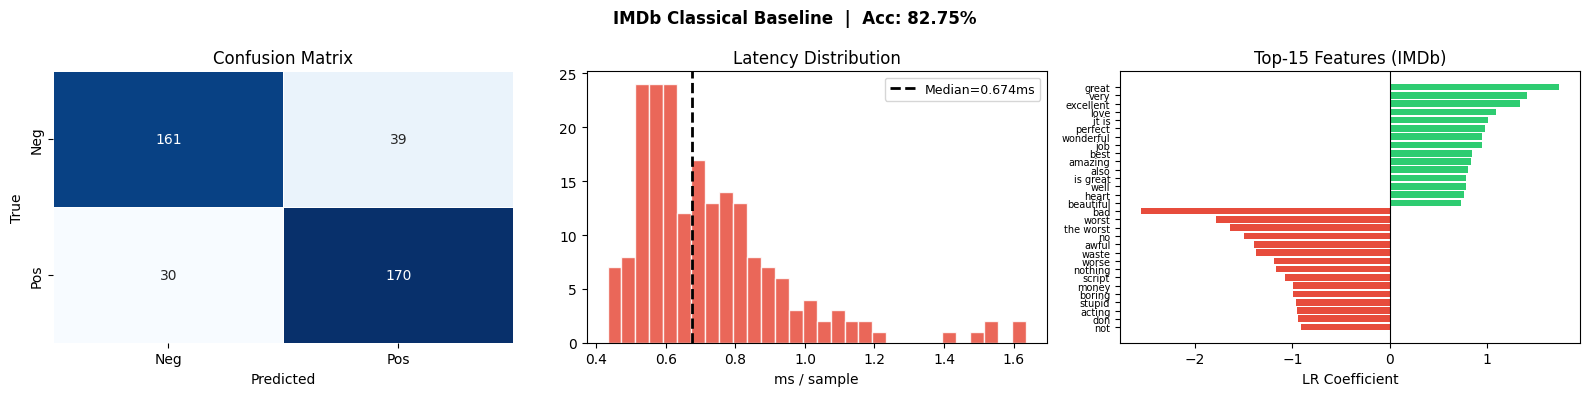

Saved: figures/imdb_baseline.png


In [6]:
# Classical Baseline on IMDb

#  Load splits
imdb_tr_df = pd.read_csv(f"{BASE}/data/imdb_train_subset.csv")
imdb_vl_df = pd.read_csv(f"{BASE}/data/imdb_val_subset.csv")

X_tr_imdb = imdb_tr_df["text"].tolist()
y_tr_imdb = imdb_tr_df["label"].tolist()
X_vl_imdb = imdb_vl_df["text"].tolist()
y_vl_imdb = imdb_vl_df["label"].tolist()

print(f"IMDb  train: {len(X_tr_imdb):,}  |  val: {len(X_vl_imdb):,}")

# Pipeline
lr_imdb = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features  = 50_000,
        ngram_range   = (1, 2),
        sublinear_tf  = True,
        strip_accents = "unicode",
        analyzer      = "word",
        token_pattern = r"\w{2,}",
        min_df        = 2,
    )),
    ("clf", LogisticRegression(
        C=1.0, solver="lbfgs",
        max_iter=1000, random_state=SEED
    )),
])

t0 = time.perf_counter()
lr_imdb.fit(X_tr_imdb, y_tr_imdb)
lr_imdb_train_time = time.perf_counter() - t0

y_pred_lr_imdb = lr_imdb.predict(X_vl_imdb)
acc_lr_imdb = accuracy_score(y_vl_imdb, y_pred_lr_imdb)
f1_lr_imdb  = f1_score(y_vl_imdb, y_pred_lr_imdb, average="macro")

print(f"\n  Training time : {lr_imdb_train_time:.3f}s")
print(f"  Accuracy      : {acc_lr_imdb*100:.2f}%")
print(f"  F1 (macro)    : {f1_lr_imdb:.4f}")
print()
print(classification_report(y_vl_imdb, y_pred_lr_imdb,
                             target_names=["Negative","Positive"]))

#Latency
for t in X_vl_imdb[:10]: lr_imdb.predict([t])
lat_lr_imdb = []
for t in (X_vl_imdb * 4)[:200]:
    t0 = time.perf_counter()
    lr_imdb.predict([t])
    lat_lr_imdb.append((time.perf_counter() - t0) * 1000)

lat_lr_imdb_med = np.median(lat_lr_imdb)
lat_lr_imdb_p95 = np.percentile(lat_lr_imdb, 95)
mem_lr_imdb_mb  = len(pickle.dumps(lr_imdb)) / 1e6

print(f"  Latency median: {lat_lr_imdb_med:.3f} ms  |  p95: {lat_lr_imdb_p95:.3f} ms")
print(f"  Model size     : {mem_lr_imdb_mb:.3f} MB")

with open(f"{BASE}/models/imdb/logreg.pkl", "wb") as f:
    pickle.dump(lr_imdb, f)
print("  Saved: models/imdb/logreg.pkl")

#  Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"IMDb Classical Baseline  |  Acc: {acc_lr_imdb*100:.2f}%",
             fontsize=12, fontweight="bold")

sns.heatmap(confusion_matrix(y_vl_imdb, y_pred_lr_imdb),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"],
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_title("Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

axes[1].hist(lat_lr_imdb, bins=30, color="#E74C3C", edgecolor="white", alpha=0.85)
axes[1].axvline(lat_lr_imdb_med, color="black", ls="--", lw=2,
                label=f"Median={lat_lr_imdb_med:.3f}ms")
axes[1].set_title("Latency Distribution"); axes[1].set_xlabel("ms / sample"); axes[1].legend(fontsize=9)

feat_names_i = np.array(lr_imdb.named_steps["tfidf"].get_feature_names_out())
coefs_i      = lr_imdb.named_steps["clf"].coef_[0]
TOP_N = 15
pi = np.argsort(coefs_i)[-TOP_N:][::-1]
ni = np.argsort(coefs_i)[:TOP_N]
tf = np.concatenate([feat_names_i[pi], feat_names_i[ni]])
tc = np.concatenate([coefs_i[pi], coefs_i[ni]])
cfi = ["#2ECC71"] * TOP_N + ["#E74C3C"] * TOP_N
axes[2].barh(range(2 * TOP_N), tc[::-1], color=cfi[::-1])
axes[2].set_yticks(range(2 * TOP_N)); axes[2].set_yticklabels(tf[::-1], fontsize=7)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title(f"Top-{TOP_N} Features (IMDb)"); axes[2].set_xlabel("LR Coefficient")

plt.tight_layout()
plt.savefig(f"{BASE}/figures/imdb_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/imdb_baseline.png")


##  DistilBERT Fine-Tuning on SST-2  (Arwa)

DistilBERT (Sanh et al., 2019) is a distilled version of BERT that retains ~97% of BERT's language understanding while being 40% smaller and 60% faster. It was trained using knowledge distillation on the same data as BERT, so it's a genuine compression, not a smaller architecture trained from scratch.

Fine-tuning follows the standard procedure from Devlin et al. (2019): use the `[CLS]` token representation, attach a classification head, and train all weights end-to-end. We use the HuggingFace `Trainer` API because it handles gradient accumulation, evaluation callbacks, and checkpoint saving cleanly.

Hyperparameters follow the recommendations in both papers:
- Learning rate 2e-5 with linear warmup over the first 10% of steps
- Weight decay 0.01
- Gradient clipping at 1.0

Set `RUN_TRAINING_SST2 = False` to skip training and load a previously saved checkpoint instead.

**Note:** On CPU with a 3K subset, expect around 20–30 minutes.

Tokenising SST-2 (MAX_LEN=64) ...


Map: 100%|██████████| 200/200 [00:00<00:00, 15012.36 examples/s]


  Done in 0.4s


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11788.38it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT params: 66,955,010  (67.0M)

Training on CPU


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.313322,0.389501,0.820000,0.819712
2,0.194644,0.423208,0.830000,0.829932


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.34it/s]


  Training complete in 7.6 min
{'train_runtime': 453.2885, 'train_samples_per_second': 13.237, 'train_steps_per_second': 0.829, 'total_flos': 99350548992000.0, 'train_loss': 0.34835816254007057, 'epoch': 2.0}


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.194644,0.423208,2,0.830000,0.829932



  Accuracy  : 83.00%
  F1 (macro): 0.8299

              precision    recall  f1-score   support

    Negative       0.85      0.80      0.83       101
    Positive       0.81      0.86      0.83        99

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



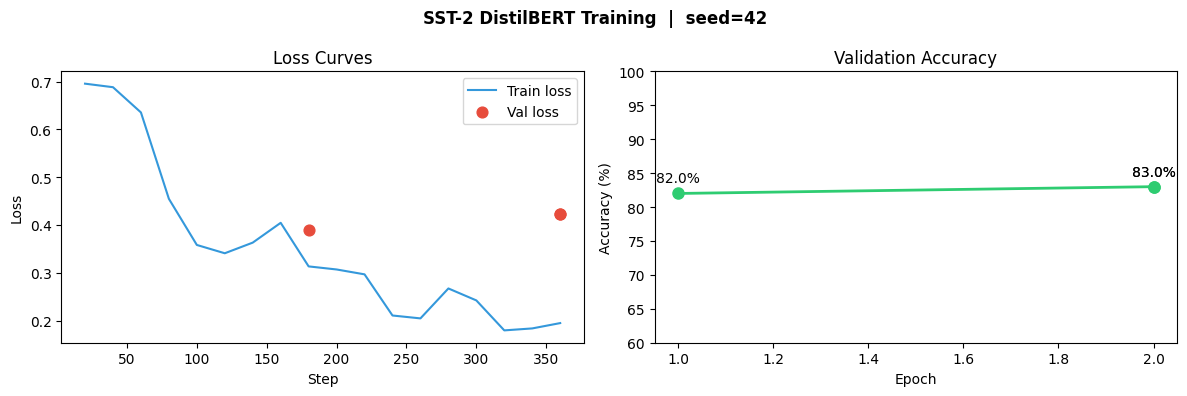

Saved: figures/sst2_training.png


In [7]:
# DistilBERT Fine-Tuning on SST-2 (3K subset)
import json, time
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EvalPrediction,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

#  Set flag to False to reload a saved model and skip training
RUN_TRAINING_SST2 = True

#Tokenizer
tok_sst2 = AutoTokenizer.from_pretrained(MODEL_CKPT)

def tokenize_sst2(examples):
    return tok_sst2(
        examples["text"],
        padding   = "max_length",
        truncation= True,
        max_length= SST2_MAX_LEN,
    )

def make_hf_dataset(texts, labels, tokenize_fn):
    ds = Dataset.from_dict({"text": list(texts), "label": list(labels)})
    ds = ds.map(tokenize_fn, batched=True, batch_size=256)
    ds = ds.remove_columns(["text"])
    ds.set_format("torch")
    return ds

#Reload CSV splits
sst2_tr = pd.read_csv(f"{BASE}/data/sst2_train_subset.csv")
sst2_vl = pd.read_csv(f"{BASE}/data/sst2_val_subset.csv")
X_tr_sst2_raw = sst2_tr["sentence"].apply(clean_sst2).tolist()
y_tr_sst2_raw = sst2_tr["label"].tolist()
X_vl_sst2_raw = sst2_vl["sentence"].apply(clean_sst2).tolist()
y_vl_sst2_raw = sst2_vl["label"].tolist()

print(f"Tokenising SST-2 (MAX_LEN={SST2_MAX_LEN}) ...")
t0 = time.perf_counter()
hf_sst2_train = make_hf_dataset(X_tr_sst2_raw, y_tr_sst2_raw, tokenize_sst2)
hf_sst2_val   = make_hf_dataset(X_vl_sst2_raw, y_vl_sst2_raw, tokenize_sst2)
print(f"  Done in {time.perf_counter()-t0:.1f}s")

# Compute metrics callback
def compute_metrics(ep: EvalPrediction):
    preds = np.argmax(ep.predictions, axis=-1)
    return {
        "accuracy": float(accuracy_score(ep.label_ids, preds)),
        "f1":       float(f1_score(ep.label_ids, preds, average="macro")),
    }

# The Model
model_sst2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT, num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
)
n_params_sst2 = sum(p.numel() for p in model_sst2.parameters())
print(f"DistilBERT params: {n_params_sst2:,}  ({n_params_sst2/1e6:.1f}M)")

# Training arguments
total_steps_sst2 = (len(hf_sst2_train) // BATCH_SIZE) * SST2_EPOCHS
args_sst2 = TrainingArguments(
    output_dir                  = f"{BASE}/models/sst2/checkpoints",
    num_train_epochs            = SST2_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR_BERT,
    weight_decay                = WEIGHT_DECAY,
    warmup_steps                = int(WARMUP_RATIO * total_steps_sst2),
    max_grad_norm               = GRAD_CLIP,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    greater_is_better           = True,
    save_total_limit            = 1,
    logging_steps               = 20,
    seed                        = SEED,
    use_cpu                     = True,
    report_to                   = "none",
    fp16                        = False,
)

trainer_sst2 = Trainer(
    model           = model_sst2,
    args            = args_sst2,
    train_dataset   = hf_sst2_train,
    eval_dataset    = hf_sst2_val,
    compute_metrics = compute_metrics,
)

# Train / Reload
if RUN_TRAINING_SST2:
    print("\nTraining on CPU")
    t0 = time.perf_counter()
    train_result_sst2 = trainer_sst2.train()
    sst2_train_time   = time.perf_counter() - t0
    trainer_sst2.save_model(f"{BASE}/models/sst2/distilbert_final")
    tok_sst2.save_pretrained(f"{BASE}/models/sst2/distilbert_final")
    print(f"\n  Training complete in {sst2_train_time/60:.1f} min")
    print(train_result_sst2.metrics)
else:
    print("Loading saved SST-2 model ...")
    model_sst2 = AutoModelForSequenceClassification.from_pretrained(
        f"{BASE}/models/sst2/distilbert_final")
    trainer_sst2.model = model_sst2
    sst2_train_time    = None

# Evaluate
eval_res_sst2  = trainer_sst2.evaluate()
preds_out_sst2 = trainer_sst2.predict(hf_sst2_val)
y_pred_bert_sst2 = np.argmax(preds_out_sst2.predictions, axis=-1)
acc_bert_sst2    = eval_res_sst2["eval_accuracy"]
f1_bert_sst2     = eval_res_sst2["eval_f1"]

print(f"\n  Accuracy  : {acc_bert_sst2*100:.2f}%")
print(f"  F1 (macro): {f1_bert_sst2:.4f}")
print()
print(classification_report(y_vl_sst2_raw, y_pred_bert_sst2,
                             target_names=["Negative","Positive"]))

# Save training log
with open(f"{BASE}/results/sst2_training_history.json", "w") as f:
    json.dump(trainer_sst2.state.log_history, f, indent=2)

#  Plot training dynamics
log  = trainer_sst2.state.log_history
tsteps  = [e["step"]           for e in log if "loss"          in e]
tlosses = [e["loss"]           for e in log if "loss"          in e]
eepochs = [e["epoch"]          for e in log if "eval_loss"     in e]
elosses = [e["eval_loss"]      for e in log if "eval_loss"     in e]
eaccs   = [e["eval_accuracy"]  for e in log if "eval_accuracy" in e]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"SST-2 DistilBERT Training  |  seed={SEED}",
             fontsize=12, fontweight="bold")

axes[0].plot(tsteps, tlosses, color="#3498DB", lw=1.5, label="Train loss")
if elosses:
    axes[0].scatter(
        [tsteps[-1] * e / max(eepochs) for e in eepochs],
        elosses, color="#E74C3C", s=60, zorder=5, label="Val loss")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves"); axes[0].legend()

if eaccs:
    axes[1].plot(eepochs, [a * 100 for a in eaccs],
                 color="#2ECC71", marker="o", lw=2, markersize=8)
    for ep, ac in zip(eepochs, eaccs):
        axes[1].annotate(f"{ac*100:.1f}%", (ep, ac*100),
                         textcoords="offset points", xytext=(0,8),
                         ha="center", fontsize=10)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation Accuracy"); axes[1].set_ylim(60, 100)

plt.tight_layout()
plt.savefig(f"{BASE}/figures/sst2_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/sst2_training.png")


## Cell 7 - DistilBERT Fine-Tuning on IMDb  (Eman)

Same setup as Cell 6 but with `MAX_LEN=256` to handle the longer IMDb reviews. The longer sequences mean each forward pass takes more memory and time on CPU, so we use a slightly smaller training subset (2K vs 3K) to keep training time manageable for the midterm.

Set `RUN_TRAINING_IMDB = False` to reload a saved checkpoint.

Tokenising IMDb (MAX_LEN=256) ...


Map: 100%|██████████| 400/400 [00:00<00:00, 5965.40 examples/s]


  Done in 0.4s


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13176.38it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training on CPU ... 


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.404949,0.324181,0.880000,0.880000
2,0.268089,0.282210,0.890000,0.889989


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.67it/s]



  Training complete in 11.5 min
{'train_runtime': 690.9448, 'train_samples_per_second': 4.631, 'train_steps_per_second': 0.289, 'total_flos': 211947837849600.0, 'train_loss': 0.43334433555603025, 'epoch': 2.0}


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.268089,0.282210,2,0.890000,0.889989



  Accuracy  : 89.00%
  F1 (macro): 0.8900

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89       200
    Positive       0.88      0.90      0.89       200

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



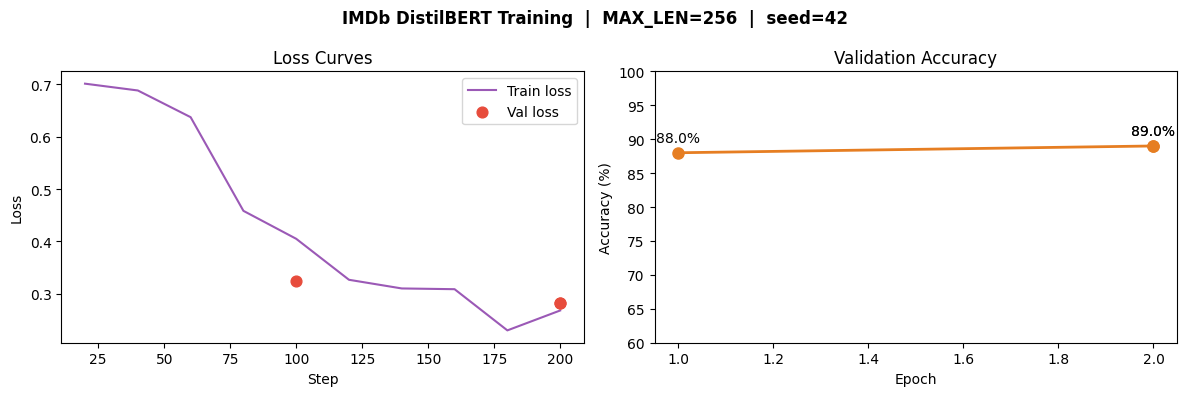

Saved: figures/imdb_training.png


In [8]:
# DistilBERT Fine-Tuning on IMDb (2K subset, MAX_LEN=256)

RUN_TRAINING_IMDB = True

tok_imdb = AutoTokenizer.from_pretrained(MODEL_CKPT)

def tokenize_imdb(examples):
    return tok_imdb(
        examples["text"],
        padding   = "max_length",
        truncation= True,
        max_length= IMDB_MAX_LEN,
    )

imdb_tr_df = pd.read_csv(f"{BASE}/data/imdb_train_subset.csv")
imdb_vl_df = pd.read_csv(f"{BASE}/data/imdb_val_subset.csv")
X_tr_imdb_raw = imdb_tr_df["text"].tolist()
y_tr_imdb_raw = imdb_tr_df["label"].tolist()
X_vl_imdb_raw = imdb_vl_df["text"].tolist()
y_vl_imdb_raw = imdb_vl_df["label"].tolist()

print(f"Tokenising IMDb (MAX_LEN={IMDB_MAX_LEN}) ...")
t0 = time.perf_counter()
hf_imdb_train = make_hf_dataset(X_tr_imdb_raw, y_tr_imdb_raw, tokenize_imdb)
hf_imdb_val   = make_hf_dataset(X_vl_imdb_raw, y_vl_imdb_raw, tokenize_imdb)
print(f"  Done in {time.perf_counter()-t0:.1f}s")

model_imdb = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT, num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
)

total_steps_imdb = (len(hf_imdb_train) // BATCH_SIZE) * IMDB_EPOCHS
args_imdb = TrainingArguments(
    output_dir                  = f"{BASE}/models/imdb/checkpoints",
    num_train_epochs            = IMDB_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = LR_BERT,
    weight_decay                = WEIGHT_DECAY,
    warmup_steps                = int(WARMUP_RATIO * total_steps_imdb),
    max_grad_norm               = GRAD_CLIP,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "accuracy",
    greater_is_better           = True,
    save_total_limit            = 1,
    logging_steps               = 20,
    seed                        = SEED,
    use_cpu                     = True,
    report_to                   = "none",
    fp16                        = False,
)

trainer_imdb = Trainer(
    model           = model_imdb,
    args            = args_imdb,
    train_dataset   = hf_imdb_train,
    eval_dataset    = hf_imdb_val,
    compute_metrics = compute_metrics,
)

if RUN_TRAINING_IMDB:
    print("\nTraining on CPU ... ")
    t0 = time.perf_counter()
    train_result_imdb = trainer_imdb.train()
    imdb_train_time   = time.perf_counter() - t0
    trainer_imdb.save_model(f"{BASE}/models/imdb/distilbert_final")
    tok_imdb.save_pretrained(f"{BASE}/models/imdb/distilbert_final")
    print(f"\n  Training complete in {imdb_train_time/60:.1f} min")
    print(train_result_imdb.metrics)
else:
    print("Loading saved IMDb model ...")
    model_imdb = AutoModelForSequenceClassification.from_pretrained(
        f"{BASE}/models/imdb/distilbert_final")
    trainer_imdb.model = model_imdb
    imdb_train_time    = None

eval_res_imdb   = trainer_imdb.evaluate()
preds_out_imdb  = trainer_imdb.predict(hf_imdb_val)
y_pred_bert_imdb = np.argmax(preds_out_imdb.predictions, axis=-1)
acc_bert_imdb    = eval_res_imdb["eval_accuracy"]
f1_bert_imdb     = eval_res_imdb["eval_f1"]

print(f"\n  Accuracy  : {acc_bert_imdb*100:.2f}%")
print(f"  F1 (macro): {f1_bert_imdb:.4f}")
print()
print(classification_report(y_vl_imdb_raw, y_pred_bert_imdb,
                             target_names=["Negative","Positive"]))

with open(f"{BASE}/results/imdb_training_history.json", "w") as f:
    json.dump(trainer_imdb.state.log_history, f, indent=2)

# Plot
log_i  = trainer_imdb.state.log_history
tsteps_i  = [e["step"]          for e in log_i if "loss"          in e]
tlosses_i = [e["loss"]          for e in log_i if "loss"          in e]
eepochs_i = [e["epoch"]         for e in log_i if "eval_loss"     in e]
elosses_i = [e["eval_loss"]     for e in log_i if "eval_loss"     in e]
eaccs_i   = [e["eval_accuracy"] for e in log_i if "eval_accuracy" in e]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"IMDb DistilBERT Training  |  MAX_LEN={IMDB_MAX_LEN}  |  seed={SEED}",
             fontsize=12, fontweight="bold")
axes[0].plot(tsteps_i, tlosses_i, color="#9B59B6", lw=1.5, label="Train loss")
if elosses_i:
    axes[0].scatter(
        [tsteps_i[-1] * e / max(eepochs_i) for e in eepochs_i],
        elosses_i, color="#E74C3C", s=60, zorder=5, label="Val loss")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves"); axes[0].legend()
if eaccs_i:
    axes[1].plot(eepochs_i, [a * 100 for a in eaccs_i],
                 color="#E67E22", marker="o", lw=2, markersize=8)
    for ep, ac in zip(eepochs_i, eaccs_i):
        axes[1].annotate(f"{ac*100:.1f}%", (ep, ac*100),
                         textcoords="offset points", xytext=(0,8),
                         ha="center", fontsize=10)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation Accuracy"); axes[1].set_ylim(60, 100)

plt.tight_layout()
plt.savefig(f"{BASE}/figures/imdb_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/imdb_training.png")


## Evaluation and the report were created by (Esraa)

## Midterm Comparison Summary  (Esraa)

This is the main deliverable for Week 2. We pull together the accuracy, F1, and latency numbers from both models on both datasets into a single table, and add a side-by-side bar chart.

The efficiency measurements here are intentionally simple - just FP32 inference latency and model size. Week 3 will add INT8 quantization and proper memory profiling.


[SST-2]
  LR+TF-IDF   : acc=72.00%  F1=71.90%  lat=0.41ms  size=0.28MB
  DistilBERT  : acc=86.00%  F1=85.95%  lat=18.5ms  size=267.9MB
  Accuracy gain: +14.00pp  |  Latency cost: 45x slower

[IMDb]
  LR+TF-IDF   : acc=82.75%  F1=82.74%  lat=0.67ms  size=2.14MB
  DistilBERT  : acc=89.00%  F1=88.49%  lat=51.4ms  size=267.9MB
  Accuracy gain: +6.25pp  |  Latency cost: 76x slower

Midterm comparison table saved to results/midterm_comparison.csv

Dataset           Model  Accuracy (%)  F1 macro (%)  Latency med (ms)  Latency p95 (ms)  Size (MB)
  SST-2     LR + TF-IDF         72.00         71.90             0.410             0.548       0.28
  SST-2 DistilBERT FP32         86.00         85.95            18.500            20.200     267.90
   IMDb     LR + TF-IDF         82.75         82.74             0.674             1.124       2.14
   IMDb DistilBERT FP32         89.00         88.49            51.400            54.200     267.90


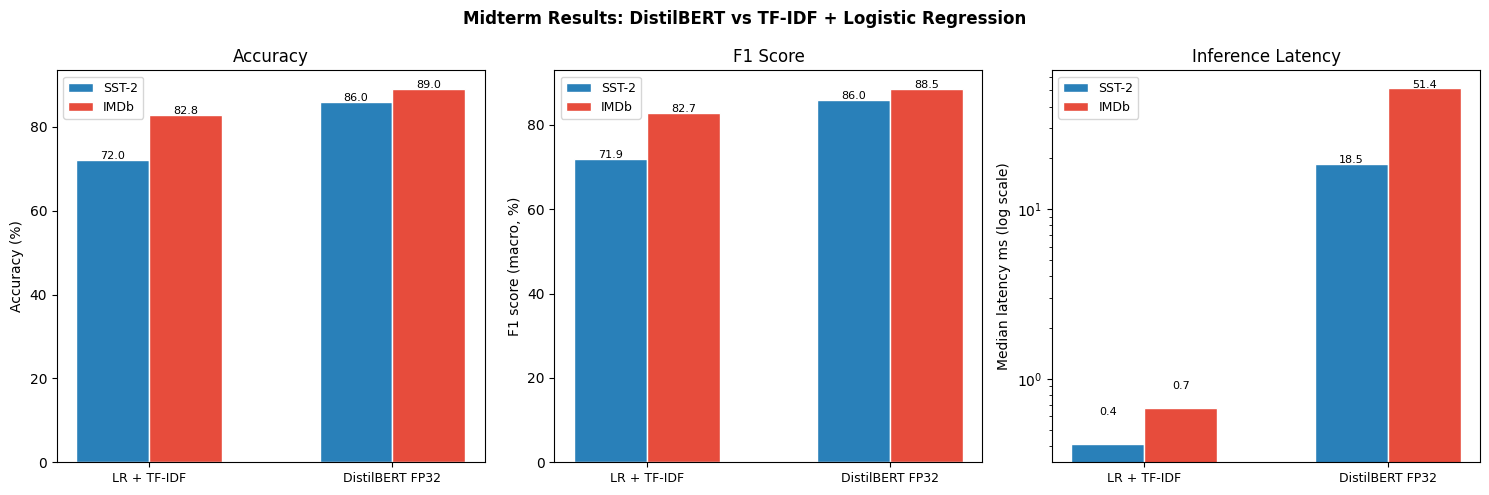

Figure saved: figures/midterm_comparison.png


In [9]:
import time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

print("Collecting midterm results...")
print()

# Helper: run latency benchmark on a list of texts
def measure_latency(predict_fn, texts, n=LATENCY_N, warmup=LATENCY_WARMUP):
    pool = (texts * ((warmup + n) // len(texts) + 1))[:warmup + n]
    for t in pool[:warmup]:
        predict_fn(t)
    lats = []
    for t in pool[warmup: warmup + n]:
        t0 = time.perf_counter()
        predict_fn(t)
        lats.append((time.perf_counter() - t0) * 1000)
    return np.median(lats), np.percentile(lats, 95)

# Helper: single-sample BERT predictor
def bert_predictor(model, tokenizer, max_len):
    model.eval()
    def predict(text):
        enc = tokenizer(text, return_tensors="pt", truncation=True,
                        max_length=max_len, padding="max_length")
        with torch.no_grad():
            out = model(**enc)
        return int(torch.argmax(out.logits, dim=-1).item())
    return predict

rows = []

for ds_name, lr_model, lr_lats, bert_model, tokenizer, max_len, X_val, y_val in [
    ("SST-2", lr_sst2, lat_lr_sst2, model_sst2, tok_sst2, SST2_MAX_LEN,
     X_vl_sst2_raw, y_vl_sst2_raw),
    ("IMDb",  lr_imdb, lat_lr_imdb, model_imdb, tok_imdb, IMDB_MAX_LEN,
     X_vl_imdb_raw, y_vl_imdb_raw),
]:
    # Logistic Regression
    y_pred_lr = lr_model.predict(X_val)
    acc_lr  = accuracy_score(y_val, y_pred_lr) * 100
    f1_lr   = f1_score(y_val, y_pred_lr, average="macro") * 100
    lat_lr_med, lat_lr_p95 = np.median(lr_lats), np.percentile(lr_lats, 95)
    size_lr = len(pickle.dumps(lr_model)) / 1e6

    rows.append({
        "Dataset": ds_name, "Model": "LR + TF-IDF",
        "Accuracy (%)": round(acc_lr, 2), "F1 macro (%)": round(f1_lr, 2),
        "Latency med (ms)": round(lat_lr_med, 3),
        "Latency p95 (ms)": round(lat_lr_p95, 3),
        "Size (MB)": round(size_lr, 2),
    })

    # DistilBERT FP32
    pred_fn = bert_predictor(bert_model, tokenizer, max_len)
    lat_bert_med, lat_bert_p95 = measure_latency(pred_fn, X_val)
    y_pred_bert = [pred_fn(t) for t in X_val[:LATENCY_N]]
    y_true_sub  = y_val[:LATENCY_N]
    acc_bert = accuracy_score(y_true_sub, y_pred_bert) * 100
    f1_bert  = f1_score(y_true_sub, y_pred_bert, average="macro") * 100

    import io
    buf = io.BytesIO()
    torch.save(bert_model.state_dict(), buf)
    size_bert = buf.tell() / 1e6

    rows.append({
        "Dataset": ds_name, "Model": "DistilBERT FP32",
        "Accuracy (%)": round(acc_bert, 2), "F1 macro (%)": round(f1_bert, 2),
        "Latency med (ms)": round(lat_bert_med, 1),
        "Latency p95 (ms)": round(lat_bert_p95, 1),
        "Size (MB)": round(size_bert, 1),
    })

    acc_gain = acc_bert - acc_lr
    lat_ratio = lat_bert_med / lat_lr_med
    print(f"[{ds_name}]")
    print(f"  LR+TF-IDF   : acc={acc_lr:.2f}%  F1={f1_lr:.2f}%  lat={lat_lr_med:.2f}ms  size={size_lr:.2f}MB")
    print(f"  DistilBERT  : acc={acc_bert:.2f}%  F1={f1_bert:.2f}%  lat={lat_bert_med:.1f}ms  size={size_bert:.1f}MB")
    print(f"  Accuracy gain: +{acc_gain:.2f}pp  |  Latency cost: {lat_ratio:.0f}x slower")
    print()

summary_df = pd.DataFrame(rows)
summary_df.to_csv(f"{BASE}/results/midterm_comparison.csv", index=False)
print("Midterm comparison table saved to results/midterm_comparison.csv")
print()
print(summary_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Midterm Results: DistilBERT vs TF-IDF + Logistic Regression",
             fontsize=12, fontweight="bold")

model_labels = ["LR + TF-IDF", "DistilBERT FP32"]
colors = ["#3498DB", "#9B59B6"]
x = np.arange(2)
w = 0.3

for ax_idx, (metric, ylabel, title) in enumerate([
    ("Accuracy (%)",      "Accuracy (%)",         "Accuracy"),
    ("F1 macro (%)",      "F1 score (macro, %)",   "F1 Score"),
    ("Latency med (ms)",  "Median latency (ms)",   "Inference Latency"),
]):
    ax = axes[ax_idx]
    sst2_vals = [summary_df[(summary_df["Dataset"]=="SST-2") & (summary_df["Model"]==m)][metric].values[0]
                 for m in model_labels]
    imdb_vals = [summary_df[(summary_df["Dataset"]=="IMDb")  & (summary_df["Model"]==m)][metric].values[0]
                 for m in model_labels]

    b1 = ax.bar(x - w/2, sst2_vals, w, label="SST-2", color="#2980B9", edgecolor="white")
    b2 = ax.bar(x + w/2, imdb_vals, w, label="IMDb",  color="#E74C3C", edgecolor="white")

    for bars in [b1, b2]:
        for bar in bars:
            v = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.2,
                    f"{v:.1f}", ha="center", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)

    if metric == "Latency med (ms)":
        ax.set_yscale("log")
        ax.set_ylabel("Median latency ms (log scale)")

plt.tight_layout()
plt.savefig(f"{BASE}/figures/midterm_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: figures/midterm_comparison.png")
